In [1]:
import os
import sys
import glob
import json
import pickle
import datetime
import numpy as np
from copy import deepcopy
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

sys.path.insert(1, '../utils')

import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

from utils import *
from mUtils import *
from plotUtils import *

%matplotlib inline
plt.rcParams.update({'font.size': 11})

In [2]:
# read parameters from a json file
with open('../params.json', 'r+') as f:
    params = json.load(f)

figureroot = "./results/system_03/lyapunov"
os.makedirs(figureroot, exist_ok=True)

In [3]:
load_dir = "../system_03/results/lyapunov/"
load_str = datetime.datetime(2025, 1, 15)
sub_dir = f"exp-{load_str.year}-{load_str.month}-{load_str.day}"

results_dir = os.path.join(load_dir, sub_dir)
file_paths = glob.glob(os.path.join(results_dir, '*.pkl'))
print(f"Total no. of files = {len(file_paths)}")

Total no. of files = 118


In [10]:
sigVar = np.array([0.1, 1, 2])
iE = 0.25 / params['gamma'] - params['i_e2']

iPert = np.array([0, 0.15, 0.25, 0.35, 0.5]) / params['gamma']
kMin = -1; kMax = 1; kSteps = 10
kVals = kMin + np.arange(0, kSteps + 1) / kSteps * (kMax - kMin)

seVals = np.array([2.5, 7.5]); seSteps = len(seVals)
siVals = np.array([4.4, 16.5]); siSteps = len(siVals) 

dt=0.05

IndexError: index 2 is out of bounds for axis 0 with size 2

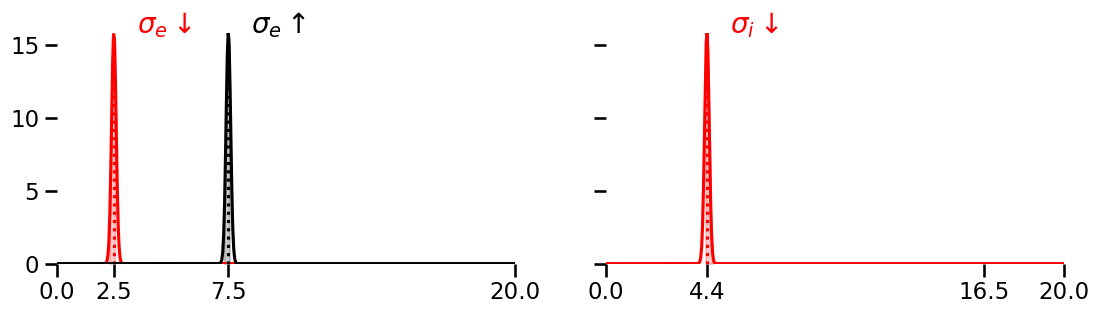

In [5]:
n_trials = 10
COLORS = ['r', 'k']

weights = np.linspace(0, 20, 500)
normdistribution = lambda x, mean, sigma : (1 / (2 * np.pi * sigma **2)) * np.exp(-(x - mean) ** 2 / (2 * sigma ** 2))



for _sigvar in sigVar:

    sige_node2 = np.zeros((seSteps, siSteps, n_trials))
    sigi_node2 = np.zeros((seSteps, siSteps, n_trials))

    for se, sigma_e in enumerate(seVals):
        for si, sigma_i in enumerate(siVals):
            for q in range(n_trials):
                np.random.seed(q * 10 + 5)
                sige2 = abs(np.random.normal(sigma_e, _sigvar, 1))
                sigi2 = abs(np.random.normal(sigma_i, _sigvar, 1))

                sige_node2[se, si, q] = sige2[0]
                sigi_node2[se, si, q] = sigi2[0]

    
    fig, axs = plt.subplots(1, 2, sharey=True, figsize=(13, 3))
    for i in range(seSteps):
        if i == 2:
            continue
        _sampledw = sige_node2[i, 0, :]
        _sampledw = np.linspace(min(_sampledw), max(_sampledw), 10)
        _samplew_prob = normdistribution(_sampledw, seVals[i], _sigvar)

        axs[0].plot(weights, normdistribution(weights, seVals[i], _sigvar), color=COLORS[i])
        axs[0].fill_between(_sampledw, _samplew_prob, color=COLORS[i], alpha=0.2)
        axs[0].axvline(seVals[i], color=COLORS[i], linestyle=":")
        
        axs[0].set_xlim(0, 20)
        axs[0].set_xticks([0, 2.5, 7.5, 20])
        axs[0].set_ylim(0, max(normdistribution(weights, seVals[i], _sigvar)))
        y_max = max(normdistribution(weights, seVals[i], _sigvar))

    for i in range(siSteps):
        if i == 1:
            continue
        _sampledw = sigi_node2[0, i, :]
        _sampledw = np.linspace(min(_sampledw), max(_sampledw), 10)
        _samplew_prob = normdistribution(_sampledw, siVals[i], _sigvar)
        axs[1].plot(weights, normdistribution(weights, siVals[i], _sigvar), color=COLORS[i//2])
        axs[1].fill_between(_sampledw, _samplew_prob, color=COLORS[i//2], alpha=0.2)
        axs[1].axvline(siVals[i], color=COLORS[i//2], linestyle=":")

        axs[1].set_xlim(0, 20)
        axs[1].set_xticks([0, 4.4, 16.5, 20])
        axs[1].set_ylim(0, max(normdistribution(weights, siVals[i], _sigvar)))
        y_max = max(normdistribution(weights, siVals[i], _sigvar))

    for pos in ["right", "left", "top", "bottom"]:
        axs[0].spines[pos].set_visible(False)
        axs[1].spines[pos].set_visible(False)

    axs[0].text(seVals[0] + 1, y_max, r"$\sigma_e \downarrow$", color='r', fontsize=20)
    axs[0].text(seVals[1] + 1, y_max, r"$\sigma_e \uparrow$", color='k', fontsize=20)
    axs[1].text(siVals[0] + 1, y_max, r"$\sigma_i \downarrow$", color='r', fontsize=20)
    axs[1].text(siVals[2] + 1, y_max, r"$\sigma_i \uparrow$", color='k', fontsize=20)

    axs[0].set_xlabel(r"Excitatory Heterogeneity parameter $(\sigma_e^2)$")
    axs[1].set_xlabel(r"Inhibitory Heterogeneity parameter $(\sigma_i^2)$")
    fig.supylabel(r"$\sqrt{Var(\sigma_x^2)} = $" + f"{_sigvar:.2f}")
    plt.tight_layout()
    plt.savefig(os.path.join(figureroot, f"samplingdistribution_var_{_sigvar:.2f}.png"), dpi=300, bbox_inches="tight")

In [11]:
_temp = []
_sortpaths = []

varInd = 1
for path_ in file_paths:
    if f"_{iE + params['i_e2']:.3f}_sigVar_{sigVar[varInd]:.2f}" not in path_:
        continue

    Basename = os.path.basename(path_).split('.pkl')[0]
    K = float(Basename.split('_K_')[-1].split('_ie_')[0])
    _temp.append(K)
    _sortpaths.append(path_)

_temp = np.array(_temp)
Ksort = np.argsort(_temp)

_sortpaths = np.array(_sortpaths)
_sortpaths = _sortpaths[Ksort]

In [12]:
Lyap = np.zeros((kSteps + 1, 4))
LyapVar = np.zeros((kSteps + 1, 4))
sigE = np.zeros((kSteps + 1, 4))
sigI = np.zeros((kSteps + 1, 4))

for nf, path_ in enumerate(_sortpaths):

    lyap_results = pickle.load(open(path_, 'rb'))

    _lyapMean = lyap_results['n1_mean']
    _lyapVar = lyap_results['n1_var']

    sigE[nf, 0] = seVals[0]; sigI[nf, 0] = siVals[0]; Lyap[nf, 0] = _lyapMean[0, 0]; LyapVar[nf, 0] = _lyapVar[0, 0]
    sigE[nf, 1] = seVals[0]; sigI[nf, 1] = siVals[-1]; Lyap[nf, 1] = _lyapMean[0, -1]; LyapVar[nf, 1] = _lyapVar[0, -1]
    sigE[nf, 2] = seVals[-1]; sigI[nf, 2] = siVals[0]; Lyap[nf, 2] = _lyapMean[-1, 0]; LyapVar[nf, 2] = _lyapVar[-1, 0]
    sigE[nf, 3] = seVals[-1]; sigI[nf, 3] = siVals[-1]; Lyap[nf, 3] = _lyapMean[-1, -1]; LyapVar[nf, 3] = _lyapVar[-1, -1]

Lyap = Lyap[:-1, :]
LyapVar = LyapVar[:-1, :]

if len(Lyap[Lyap != -np.inf].flatten()) == 0:
    minValue = -10
else:
    minValue = min(-10, min(Lyap[Lyap != -np.inf]))
Lyap[Lyap == -np.inf] = minValue

nanMask = np.isnan(LyapVar)
LyapVar[nanMask] = 0.0

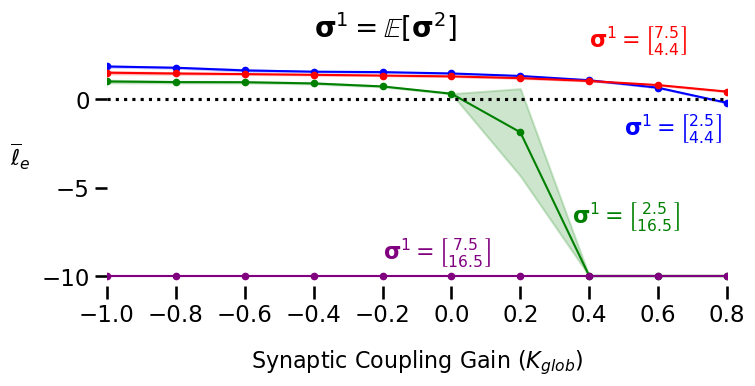

In [13]:
colors= plt.get_cmap('jet')
colorIter = iter(colors(np.linspace(0.3, 1, 4)))

plt.figure(figsize=(8, 3))

plt.plot(kVals[:-1], Lyap[:, 0], '.-', color = 'b', linewidth=1.5)
plt.fill_between(kVals[:-1], Lyap[:, 0] - LyapVar[:, 0], Lyap[:, 0] + LyapVar[:, 0], color="b", alpha=0.2)
plt.text(0.5, -2., r'$\mathbf{\sigma}^1 = \genfrac{[}{]}{0}{1}{2.5}{4.4}$', color = 'b',  fontsize=16)

plt.plot(kVals[:-1], Lyap[:, 1], '.-', color = 'g', linewidth=1.5)
plt.fill_between(kVals[:-1], Lyap[:, 1] - LyapVar[:, 1], Lyap[:, 1] + LyapVar[:, 1], color="g", alpha=0.2)
plt.text(0.35, -7, r'$\mathbf{\sigma}^1 = \genfrac{[}{]}{0}{1}{2.5}{16.5}$', color = 'g',  fontsize=16)

plt.plot(kVals[:-1], Lyap[:, 2], '.-', color = 'r', linewidth=1.5)
plt.fill_between(kVals[:-1], Lyap[:, 2] - LyapVar[:, 2], Lyap[:, 2] + LyapVar[:, 2], color="r", alpha=0.2)
plt.text(0.4, 3, r'$\mathbf{\sigma}^1 = \genfrac{[}{]}{0}{1}{7.5}{4.4}$', color = 'r',  fontsize=16)

plt.plot(kVals[:-1], Lyap[:, 3], '.-', color = 'purple', linewidth=1.5)
plt.fill_between(kVals[:-1], Lyap[:, 3] - LyapVar[:, 3], Lyap[:, 3] + LyapVar[:, 3], color="purple", alpha=0.2)
plt.text(-0.2, -9, r'$\mathbf{\sigma}^1 = \genfrac{[}{]}{0}{1}{7.5}{16.5}$', color = 'purple',  fontsize=16)

plt.text(-0.4, 3.5, r"$\mathbf{\sigma}^1 = \mathbb{E}[\mathbf{\sigma}^2]$", fontsize=20)
plt.axhline(y=0, color = 'k', linestyle=':')
plt.ylabel(r"$\overline{\ell}_e$", fontsize=16, rotation=0, labelpad=15)
plt.xlabel(r"Synaptic Coupling Gain $(K_{glob})$", fontsize=16, labelpad=15)
plt.xlim(kMin, max(kVals[:-1]))
for pos in ["right", "left", "top", "bottom"]:
    plt.gca().spines[pos].set_visible(False)
plt.savefig(os.path.join(figureroot, f"Imod_{iE:.3f}mV_sigVar_{sigVar[varInd]:.2f}_dt_{dt}ms_K.png"), dpi=300, bbox_inches='tight')
    

In [14]:
Lyap = np.zeros((len(sigVar), kSteps + 1, 4))
LyapVar = np.zeros((len(sigVar), kSteps + 1, 4))
sigE = np.zeros((len(sigVar), kSteps + 1, 4))
sigI = np.zeros((len(sigVar), kSteps + 1, 4))

for varInd in range(len(sigVar)):
    _temp = []
    _sortpaths = []

    for path_ in file_paths:
        if f"_{iE + params['i_e2']:.3f}_sigVar_{sigVar[varInd]:.2f}" not in path_:
            continue

        Basename = os.path.basename(path_).split('.pkl')[0]
        K = float(Basename.split('_K_')[-1].split('_ie_')[0])
        _temp.append(K)
        _sortpaths.append(path_)

    _temp = np.array(_temp)
    Ksort = np.argsort(_temp)

    _sortpaths = np.array(_sortpaths)
    _sortpaths = _sortpaths[Ksort]
 
    for nf, path_ in enumerate(_sortpaths):

        lyap_results = pickle.load(open(path_, 'rb'))

        _lyapMean = lyap_results['n1_mean']
        _lyapVar = lyap_results['n1_var']

        Lyap[varInd, nf, 0] = _lyapMean[0, 0]; LyapVar[varInd, nf, 0] = _lyapVar[0, 0]
        Lyap[varInd, nf, 1] = _lyapMean[0, -1]; LyapVar[varInd, nf, 1] = _lyapVar[0, -1]
        Lyap[varInd, nf, 2] = _lyapMean[-2, 0]; LyapVar[varInd, nf, 2] = _lyapVar[-2, 0]
        Lyap[varInd, nf, 3] = _lyapMean[-2, -1]; LyapVar[varInd, nf, 3] = _lyapVar[-2, -1]

Lyap = Lyap[:, :-1, :]
LyapVar = LyapVar[:, :-1, :]

if len(Lyap[Lyap != -np.inf].flatten()) == 0:
    minValue = -10
else:
    minValue = min(-10, min(Lyap[Lyap != -np.inf]))
Lyap[Lyap == -np.inf] = minValue

nanMask = np.isnan(LyapVar)
LyapVar[nanMask] = 0.0

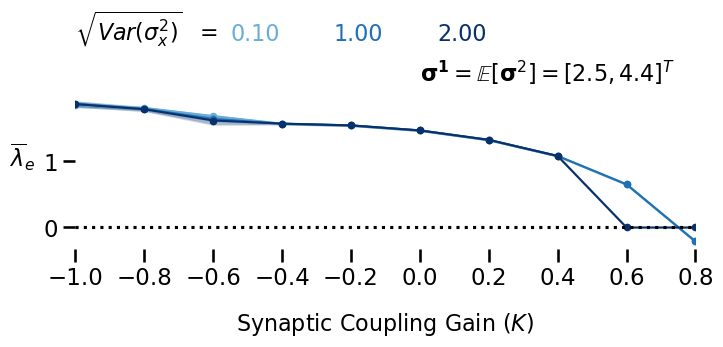

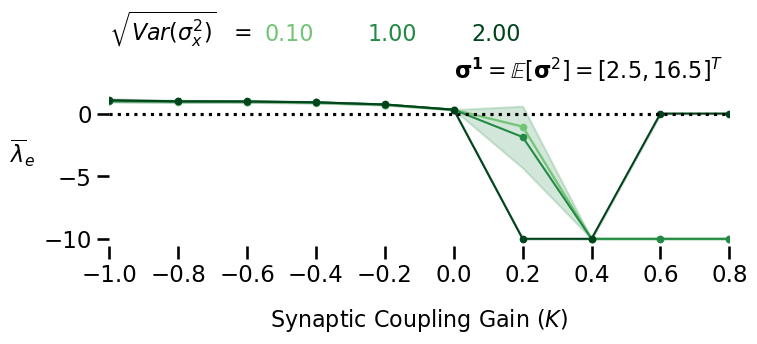

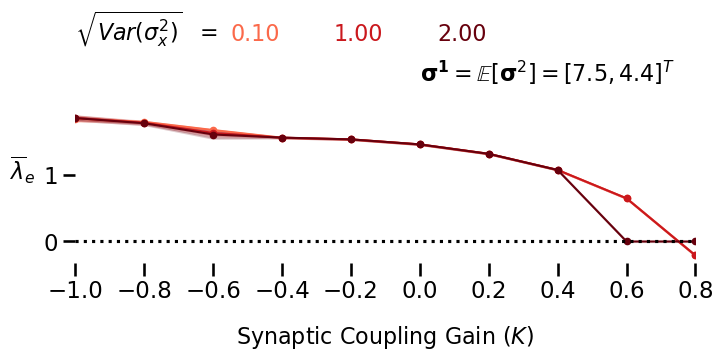

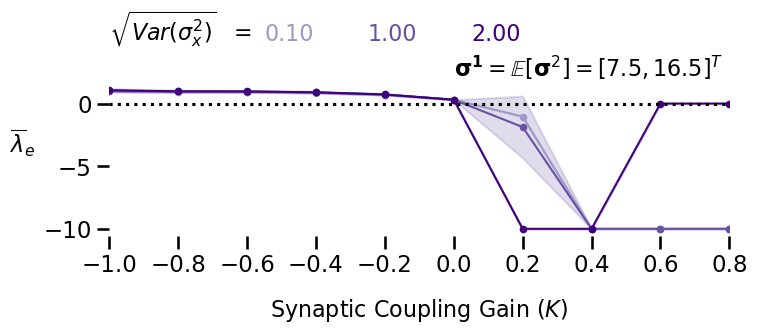

In [15]:
colors= plt.get_cmap('Blues')
colorIter = iter(colors(np.linspace(0.5, 1, len(sigVar))))

plt.figure(figsize=(8, 2))
plt.text(-1, 2.8, r'$\sqrt{Var(\sigma_x^2)} ~~= $', color = 'k',  fontsize=16)

for i in range(len(sigVar)):
    color = next(colorIter)
    plt.plot(kVals[:-1], Lyap[i, :, 0], '.-', color=color, linewidth=1.5)
    plt.fill_between(kVals[:-1], Lyap[i, :, 0] - LyapVar[i, :, 0], Lyap[i, :, 0] + LyapVar[i, :, 0], color=color, alpha=0.2)
    plt.text(-0.55 + 0.3 * i, 2.8, f"{sigVar[i]:.2f}", color = color,  fontsize=16)

plt.text(0, 2.2, r"$\mathbf{\sigma^1} = \mathbb{E}[\mathbf{\sigma}^2] = [2.5, 4.4]^T$", color = "k",  fontsize=16)
for pos in ["right", "left", "top", "bottom"]:
    plt.gca().spines[pos].set_visible(False)

plt.axhline(0, color='k', linestyle=':')
plt.xlim(kMin, kVals[-2])
plt.ylabel(r"$\overline{\lambda}_e$", fontsize=16, rotation=0, labelpad=15)
plt.xlabel(r"Synaptic Coupling Gain $(K)$", fontsize=16, labelpad=15)
plt.savefig(os.path.join(figureroot, f"Imod_{iE:.3f}mV_sige_2.5_sigi_4.4_K.png"), dpi=300, bbox_inches="tight")
plt.show()

#----------------------------------------------------------------------------------------------------------------------------#
colors= plt.get_cmap('Greens')
colorIter = iter(colors(np.linspace(0.5, 1, len(sigVar))))

plt.figure(figsize=(8, 2))
plt.text(-1, 5.8, r'$\sqrt{Var(\sigma_x^2)} ~~= $', color = 'k',  fontsize=16)

for i in range(len(sigVar)):
    color = next(colorIter)
    plt.plot(kVals[:-1], Lyap[i, :, 1], '.-', color=color, linewidth=1.5)
    plt.fill_between(kVals[:-1], Lyap[i, :, 1] - LyapVar[i, :, 1], Lyap[i, :, 1] + LyapVar[i, :, 1], color=color, alpha=0.2)
    plt.text(-0.55 + 0.3 * i, 5.8, f"{sigVar[i]:.2f}", color = color,  fontsize=16)

plt.text(0, 2.8, r"$\mathbf{\sigma^1} = \mathbb{E}[\mathbf{\sigma}^2] = [2.5, 16.5]^T$", color = "k",  fontsize=16)
for pos in ["right", "left", "top", "bottom"]:
    plt.gca().spines[pos].set_visible(False)

plt.axhline(0, color='k', linestyle=':')
plt.xlim(kMin, kVals[-2])
plt.ylabel(r"$\overline{\lambda}_e$", fontsize=16, rotation=0, labelpad=15)
plt.xlabel(r"Synaptic Coupling Gain $(K)$", fontsize=16, labelpad=15)
plt.savefig(os.path.join(figureroot, f"Imod_{iE:.3f}mV_sige_2.5_sigi_16.5_K.png"), dpi=300, bbox_inches="tight")
plt.show()

#----------------------------------------------------------------------------------------------------------------------------#
colors= plt.get_cmap('Reds')
colorIter = iter(colors(np.linspace(0.5, 1, len(sigVar))))

plt.figure(figsize=(8, 2))
plt.text(-1, 3, r'$\sqrt{Var(\sigma_x^2)} ~~= $', color = 'k',  fontsize=16)

for i in range(len(sigVar)):
    color = next(colorIter)
    plt.plot(kVals[:-1], Lyap[i, :, 2], '.-', color=color, linewidth=1.5)
    plt.fill_between(kVals[:-1], Lyap[i, :, 2] - LyapVar[i, :, 2], Lyap[i, :, 2] + LyapVar[i, :, 2], color=color, alpha=0.2)
    plt.text(-0.55 + 0.3 * i, 3, f"{sigVar[i]:.2f}", color = color,  fontsize=16)

plt.text(0, 2.4, r"$\mathbf{\sigma^1} = \mathbb{E}[\mathbf{\sigma}^2] = [7.5, 4.4]^T$", color = "k",  fontsize=16)
for pos in ["right", "left", "top", "bottom"]:
    plt.gca().spines[pos].set_visible(False)

plt.axhline(0, color='k', linestyle=':')
plt.xlim(kMin, kVals[-2])
plt.ylabel(r"$\overline{\lambda}_e$", fontsize=16, rotation=0, labelpad=15)
plt.xlabel(r"Synaptic Coupling Gain $(K)$", fontsize=16, labelpad=15)
plt.savefig(os.path.join(figureroot, f"Imod_{iE:.3f}mV_sige_7.5_sigi_4.4_K.png"), dpi=300, bbox_inches="tight")
plt.show()

#----------------------------------------------------------------------------------------------------------------------------#
colors= plt.get_cmap('Purples')
colorIter = iter(colors(np.linspace(0.5, 1, len(sigVar))))

plt.figure(figsize=(8, 2))
plt.text(-1, 5, r'$\sqrt{Var(\sigma_x^2)} ~~= $', color = 'k',  fontsize=16)

for i in range(len(sigVar)):
    color = next(colorIter)
    plt.plot(kVals[:-1], Lyap[i, :, 3], '.-', color=color, linewidth=1.5)
    plt.fill_between(kVals[:-1], Lyap[i, :, 3] - LyapVar[i, :, 3], Lyap[i, :, 3] + LyapVar[i, :, 3], color=color, alpha=0.2)
    plt.text(-0.55 + 0.3 * i, 5, f"{sigVar[i]:.2f}", color = color,  fontsize=16)

plt.text(0, 2.2, r"$\mathbf{\sigma^1} = \mathbb{E}[\mathbf{\sigma}^2] = [7.5, 16.5]^T$", color = "k",  fontsize=16)
for pos in ["right", "left", "top", "bottom"]:
    plt.gca().spines[pos].set_visible(False)

plt.axhline(0, color='k', linestyle=':')
plt.xlim(kMin, kVals[-2])
plt.ylabel(r"$\overline{\lambda}_e$", fontsize=16, rotation=0, labelpad=15)
plt.xlabel(r"Synaptic Coupling Gain $(K)$", fontsize=16, labelpad=15)   
plt.savefig(os.path.join(figureroot, f"Imod_{iE:.3f}mV_sige_7.5_sigi_16.5_K.png"), dpi=300, bbox_inches="tight")
plt.show()

In [11]:
Lyap = np.zeros((len(sigVar), len(iPert), 4))
LyapVar = np.zeros((len(sigVar), len(iPert), 4))
sigE = np.zeros((len(sigVar), len(iPert), 4))
sigI = np.zeros((len(sigVar), len(iPert), 4))

K = -0.2

for varInd in range(len(sigVar)):
    _temp = []
    _sortpaths = []

    for path_ in file_paths:
        if f"_K_{K:.2f}" not in path_ or f"_sigVar_{sigVar[varInd]:.2f}" not in path_:
            continue
        Basename = os.path.basename(path_).split('.pkl')[0]
        I = float(Basename.split('_ie_')[-1].split("_sigVar_")[0])
        _temp.append(I)
        _sortpaths.append(path_)

    _temp = np.array(_temp)
    Isort = np.argsort(_temp)

    _sortpaths = np.array(_sortpaths)
    _sortpaths = _sortpaths[Isort]
    iVals = _temp[Isort]
    iVals -= params['i_e2']

    for nf, path_ in enumerate(_sortpaths):
        lyap_results = pickle.load(open(path_, 'rb'))

        _lyapMean = lyap_results['n1_mean']
        _lyapVar = lyap_results['n1_var']

        Lyap[varInd, nf, 0] = _lyapMean[0, 0]; LyapVar[varInd, nf, 0] = _lyapVar[0, 0]
        Lyap[varInd, nf, 1] = _lyapMean[0, -1]; LyapVar[varInd, nf, 1] = _lyapVar[0, -1]
        Lyap[varInd, nf, 2] = _lyapMean[-2, 0]; LyapVar[varInd, nf, 2] = _lyapVar[-2, 0]
        Lyap[varInd, nf, 3] = _lyapMean[-2, -1]; LyapVar[varInd, nf, 3] = _lyapVar[-2, -1]

if len(Lyap[Lyap != -np.inf].flatten()) == 0:
    minValue = -10
else:
    minValue = min(-10, min(Lyap[Lyap != -np.inf]))
Lyap[Lyap == -np.inf] = minValue

nanMask = np.isnan(LyapVar)
LyapVar[nanMask] = 0.0   

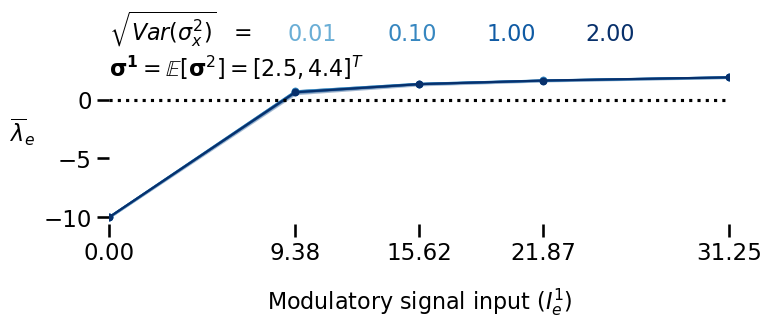

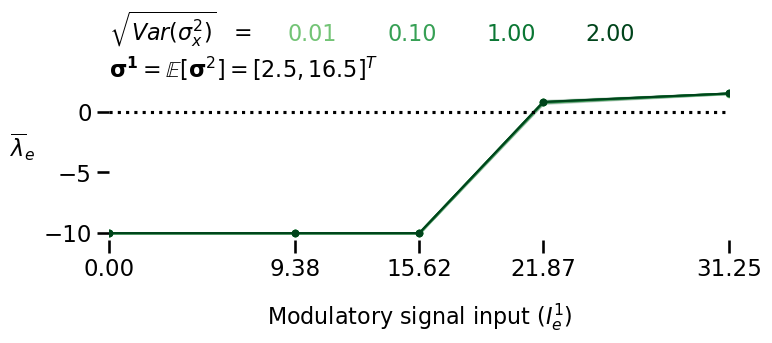

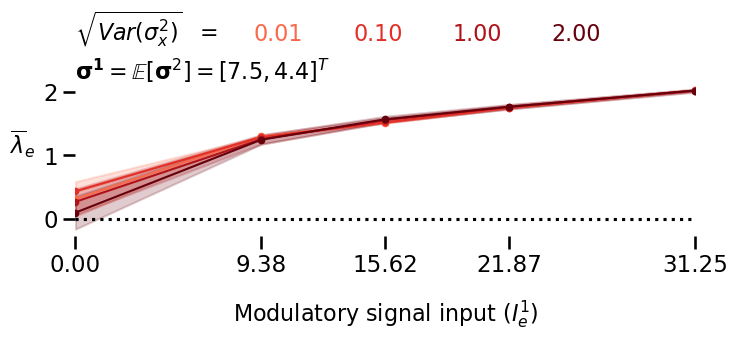

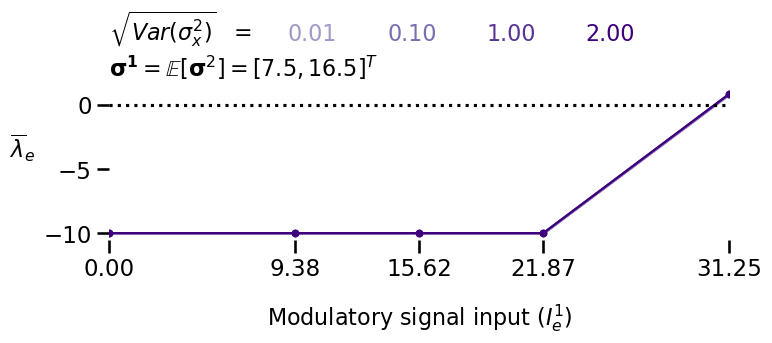

In [12]:
colors= plt.get_cmap('Blues')
colorIter = iter(colors(np.linspace(0.5, 1, len(sigVar))))

plt.figure(figsize=(8, 2))
plt.text(0, 5, r'$\sqrt{Var(\sigma_x^2)} ~~= $', color = 'k',  fontsize=16)

for i in range(len(sigVar)):
    color = next(colorIter)
    plt.plot(iPert, Lyap[i, :, 0], '.-', color=color, linewidth=1.5)
    plt.fill_between(iPert, Lyap[i, :, 0] - LyapVar[i, :, 0], Lyap[i, :, 0] + LyapVar[i, :, 0], color=color, alpha=0.2)
    plt.text(9 + 5 * i, 5, f"{sigVar[i]:.2f}", color = color,  fontsize=16)

plt.text(0, 2.0, r"$\mathbf{\sigma^1} = \mathbb{E}[\mathbf{\sigma}^2] = [2.5, 4.4]^T$", color = "k",  fontsize=16)
for pos in ["right", "left", "top", "bottom"]:
    plt.gca().spines[pos].set_visible(False)

plt.axhline(0, color='k', linestyle=':')
plt.xlim(min(iPert), max(iPert))
plt.xticks(iPert)
plt.ylabel(r"$\overline{\lambda}_e$", fontsize=16, rotation=0, labelpad=15)
plt.xlabel(r"Modulatory signal input $(I^1_e)$", fontsize=16, labelpad=15)
plt.savefig(os.path.join(figureroot, f"K_{K:.2f}_sige_2.5_sigi_4.4_I.png"), dpi=300, bbox_inches="tight")
plt.show()

#----------------------------------------------------------------------------------------------------------------------------#
colors= plt.get_cmap('Greens')
colorIter = iter(colors(np.linspace(0.5, 1, len(sigVar))))

plt.figure(figsize=(8, 2))
plt.text(0., 5.8, r'$\sqrt{Var(\sigma_x^2)} ~~= $', color = 'k',  fontsize=16)

for i in range(len(sigVar)):
    color = next(colorIter)
    plt.plot(iPert, Lyap[i, :, 1], '.-', color=color, linewidth=1.5)
    plt.fill_between(iPert, Lyap[i, :, 1] - LyapVar[i, :, 1], Lyap[i, :, 1] + LyapVar[i, :, 1], color=color, alpha=0.2)
    plt.text(9 + 5 * i, 5.8, f"{sigVar[i]:.2f}", color = color,  fontsize=16)

plt.text(0, 2.8, r"$\mathbf{\sigma^1} = \mathbb{E}[\mathbf{\sigma}^2] = [2.5, 16.5]^T$", color = "k",  fontsize=16)
for pos in ["right", "left", "top", "bottom"]:
    plt.gca().spines[pos].set_visible(False)

plt.axhline(0, color='k', linestyle=':')
plt.xlim(min(iPert), max(iPert))
plt.xticks(iPert)
plt.ylabel(r"$\overline{\lambda}_e$", fontsize=16, rotation=0, labelpad=15)
plt.xlabel(r"Modulatory signal input $(I^1_e)$", fontsize=16, labelpad=15)
plt.savefig(os.path.join(figureroot, f"K_{K:.2f}_sige_2.5_sigi_16.5_I.png"), dpi=300, bbox_inches="tight")
plt.show()

#----------------------------------------------------------------------------------------------------------------------------#
colors= plt.get_cmap('Reds')
colorIter = iter(colors(np.linspace(0.5, 1, len(sigVar))))

plt.figure(figsize=(8, 2))
plt.text(0., 2.8, r'$\sqrt{Var(\sigma_x^2)} ~~= $', color = 'k',  fontsize=16)

for i in range(len(sigVar)):
    color = next(colorIter)
    plt.plot(iPert, Lyap[i, :, 2], '.-', color=color, linewidth=1.5)
    plt.fill_between(iPert, Lyap[i, :, 2] - LyapVar[i, :, 2], Lyap[i, :, 2] + LyapVar[i, :, 2], color=color, alpha=0.2)
    plt.text(9 + 5 * i, 2.8, f"{sigVar[i]:.2f}", color = color,  fontsize=16)

plt.text(0, 2.2, r"$\mathbf{\sigma^1} = \mathbb{E}[\mathbf{\sigma}^2] = [7.5, 4.4]^T$", color = "k",  fontsize=16)
for pos in ["right", "left", "top", "bottom"]:
    plt.gca().spines[pos].set_visible(False)

plt.axhline(0, color='k', linestyle=':')
plt.xlim(min(iPert), max(iPert))
plt.xticks(iPert)
plt.ylabel(r"$\overline{\lambda}_e$", fontsize=16, rotation=0, labelpad=15)
plt.xlabel(r"Modulatory signal input $(I^1_e)$", fontsize=16, labelpad=15)
plt.savefig(os.path.join(figureroot, f"K_{K:.2f}_sige_7.5_sigi_4.4_I.png"), dpi=300, bbox_inches="tight")
plt.show()

#----------------------------------------------------------------------------------------------------------------------------#
colors= plt.get_cmap('Purples')
colorIter = iter(colors(np.linspace(0.5, 1, len(sigVar))))

plt.figure(figsize=(8, 2))
plt.text(0., 5, r'$\sqrt{Var(\sigma_x^2)} ~~= $', color = 'k',  fontsize=16)

for i in range(len(sigVar)):
    color = next(colorIter)
    plt.plot(iPert, Lyap[i, :, 3], '.-', color=color, linewidth=1.5)
    plt.fill_between(iPert, Lyap[i, :, 3] - LyapVar[i, :, 3], Lyap[i, :, 3] + LyapVar[i, :, 3], color=color, alpha=0.2)
    plt.text(9 + 5 * i, 5, f"{sigVar[i]:.2f}", color = color,  fontsize=16)

plt.text(0, 2.2, r"$\mathbf{\sigma^1} = \mathbb{E}[\mathbf{\sigma}^2] = [7.5, 16.5]^T$", color = "k",  fontsize=16)
for pos in ["right", "left", "top", "bottom"]:
    plt.gca().spines[pos].set_visible(False)

plt.axhline(0, color='k', linestyle=':')
plt.xlim(min(iPert), max(iPert))
plt.xticks(iPert)
plt.ylabel(r"$\overline{\lambda}_e$", fontsize=16, rotation=0, labelpad=15)
plt.xlabel(r"Modulatory signal input $(I^1_e)$", fontsize=16, labelpad=15)   
plt.savefig(os.path.join(figureroot, f"K_{K:.2f}_sige_7.5_sigi_16.5_I.png"), dpi=300, bbox_inches="tight")
plt.show()

In [13]:
load_dir = "../system_03/results/lyapunov/"
load_str = datetime.datetime(2024, 4, 1)
sub_dir = f"exp-{load_str.year}-{load_str.month}-{load_str.day}"

results_dir = os.path.join(load_dir, sub_dir)
file_paths = glob.glob(os.path.join(results_dir, '*.pkl'))
print(f"Total no. of files = {len(file_paths)}")

Total no. of files = 220


In [14]:
sigVar = np.array([0.01, 0.1, 1, 2])
iE = 0.25 / params['gamma'] - params['i_e2']

iPert = np.array([0, 0.15, 0.25, 0.35, 0.5]) / params['gamma']
kMin = -1; kMax = 1; kSteps = 10
kVals = kMin + np.arange(0, kSteps + 1) / kSteps * (kMax - kMin)

seVals = np.array([2.5, 7.5]); seSteps = len(seVals)
siVals = np.array([4.4, 16.5]); siSteps = len(siVals) 

In [15]:
_temp = []
_sortpaths = []

varInd = 3
for path_ in file_paths:
    if f"_{iE + params['i_e2']:.3f}_sigVar_{sigVar[varInd]:.2f}" not in path_:
        continue

    Basename = os.path.basename(path_).split('.pkl')[0]
    K = float(Basename.split('_K_')[-1].split('_ie_')[0])
    _temp.append(K)
    _sortpaths.append(path_)

_temp = np.array(_temp)
Ksort = np.argsort(_temp)

_sortpaths = np.array(_sortpaths)
_sortpaths = _sortpaths[Ksort]

In [16]:
Lyap = np.zeros((kSteps + 1, 4))
LyapVar = np.zeros((kSteps + 1, 4))

for nf, path_ in enumerate(_sortpaths):

    lyap_results = pickle.load(open(path_, 'rb'))

    _lyapMean = lyap_results['n1_mean']
    _lyapVar = lyap_results['n1_var']

    Lyap[nf, 0] = _lyapMean[0, 0]; LyapVar[nf, 0] = _lyapVar[0, 0]
    Lyap[nf, 1] = _lyapMean[0, -1]; LyapVar[nf, 1] = _lyapVar[0, -1]
    Lyap[nf, 2] = _lyapMean[-1, 0]; LyapVar[nf, 2] = _lyapVar[-1, 0]
    Lyap[nf, 3] = _lyapMean[-1, -1]; LyapVar[nf, 3] = _lyapVar[-1, -1]

Lyap = Lyap[:-1, :]
LyapVar = LyapVar[:-1, :]

if len(Lyap[Lyap != -np.inf].flatten()) == 0:
    minValue = -10
else:
    minValue = min(-10, min(Lyap[Lyap != -np.inf]))
Lyap[Lyap == -np.inf] = minValue

nanMask = np.isnan(LyapVar)
LyapVar[nanMask] = 0.0

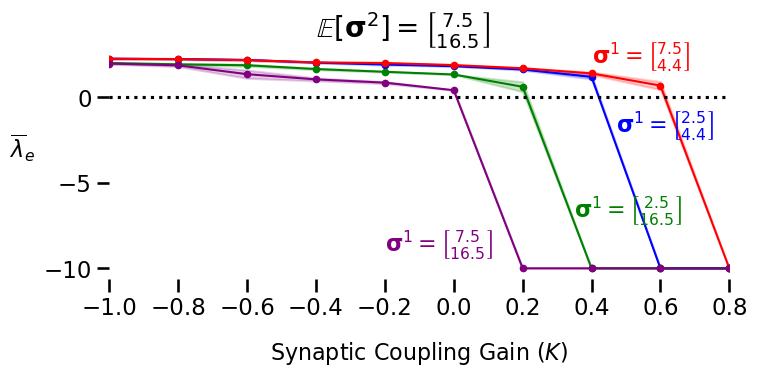

In [17]:
colors= plt.get_cmap('jet')
colorIter = iter(colors(np.linspace(0.3, 1, 4)))

plt.figure(figsize=(8, 3))

plt.plot(kVals[:-1], Lyap[:, 0], '.-', color = 'b', linewidth=1.5)
plt.fill_between(kVals[:-1], Lyap[:, 0] - LyapVar[:, 0], Lyap[:, 0] + LyapVar[:, 0], color="b", alpha=0.2)
plt.text(0.47, -2., r'$\mathbf{\sigma}^1 = \genfrac{[}{]}{0}{1}{2.5}{4.4}$', color = 'b',  fontsize=16)

plt.plot(kVals[:-1], Lyap[:, 1], '.-', color = 'g', linewidth=1.5)
plt.fill_between(kVals[:-1], Lyap[:, 1] - LyapVar[:, 1], Lyap[:, 1] + LyapVar[:, 1], color="g", alpha=0.2)
plt.text(0.35, -7, r'$\mathbf{\sigma}^1 = \genfrac{[}{]}{0}{1}{2.5}{16.5}$', color = 'g',  fontsize=16)

plt.plot(kVals[:-1], Lyap[:, 2], '.-', color = 'r', linewidth=1.5)
plt.fill_between(kVals[:-1], Lyap[:, 2] - LyapVar[:, 2], Lyap[:, 2] + LyapVar[:, 2], color="r", alpha=0.2)
plt.text(0.4, 2, r'$\mathbf{\sigma}^1 = \genfrac{[}{]}{0}{1}{7.5}{4.4}$', color = 'r',  fontsize=16)

plt.plot(kVals[:-1], Lyap[:, 3], '.-', color = 'purple', linewidth=1.5)
plt.fill_between(kVals[:-1], Lyap[:, 3] - LyapVar[:, 3], Lyap[:, 3] + LyapVar[:, 3], color="purple", alpha=0.2)
plt.text(-0.2, -9, r'$\mathbf{\sigma}^1 = \genfrac{[}{]}{0}{1}{7.5}{16.5}$', color = 'purple',  fontsize=16)

plt.text(-0.4, 3.5, r"$\mathbb{E}[\mathbf{\sigma}^2]= \genfrac{[}{]}{0}{1}{7.5}{16.5}$", fontsize=20)
plt.axhline(y=0, color = 'k', linestyle=':')
plt.ylabel(r"$\overline{\lambda}_e$", fontsize=16, rotation=0, labelpad=15)
plt.xlabel(r"Synaptic Coupling Gain $(K)$", fontsize=16, labelpad=15)
plt.xlim(kMin, max(kVals[:-1]))
for pos in ["right", "left", "top", "bottom"]:
    plt.gca().spines[pos].set_visible(False)
plt.savefig(os.path.join(figureroot, f"Imod_{iE:.3f}mV_sigVar_{sigVar[varInd]:.2f}_K_Het2Node.png"), dpi=300, bbox_inches='tight')
    

In [18]:
Lyap = np.zeros((len(sigVar), kSteps + 1, 4))
LyapVar = np.zeros((len(sigVar), kSteps + 1, 4))
sigE = np.zeros((len(sigVar), kSteps + 1, 4))
sigI = np.zeros((len(sigVar), kSteps + 1, 4))

for varInd in range(len(sigVar)):
    _temp = []
    _sortpaths = []

    for path_ in file_paths:
        if f"_{iE + params['i_e2']:.3f}_sigVar_{sigVar[varInd]:.2f}" not in path_:
            continue

        Basename = os.path.basename(path_).split('.pkl')[0]
        K = float(Basename.split('_K_')[-1].split('_ie_')[0])
        _temp.append(K)
        _sortpaths.append(path_)

    _temp = np.array(_temp)
    Ksort = np.argsort(_temp)

    _sortpaths = np.array(_sortpaths)
    _sortpaths = _sortpaths[Ksort]
 
    for nf, path_ in enumerate(_sortpaths):

        lyap_results = pickle.load(open(path_, 'rb'))

        _lyapMean = lyap_results['n1_mean']
        _lyapVar = lyap_results['n1_var']

        Lyap[varInd, nf, 0] = _lyapMean[0, 0]; LyapVar[varInd, nf, 0] = _lyapVar[0, 0]
        Lyap[varInd, nf, 1] = _lyapMean[0, -1]; LyapVar[varInd, nf, 1] = _lyapVar[0, -1]
        Lyap[varInd, nf, 2] = _lyapMean[-1, 0]; LyapVar[varInd, nf, 2] = _lyapVar[-1, 0]
        Lyap[varInd, nf, 3] = _lyapMean[-1, -1]; LyapVar[varInd, nf, 3] = _lyapVar[-1, -1]

Lyap = Lyap[:, :-1, :]
LyapVar = LyapVar[:, :-1, :]

if len(Lyap[Lyap != -np.inf].flatten()) == 0:
    minValue = -10
else:
    minValue = min(-10, min(Lyap[Lyap != -np.inf]))
Lyap[Lyap == -np.inf] = minValue

nanMask = np.isnan(LyapVar)
LyapVar[nanMask] = 0.0

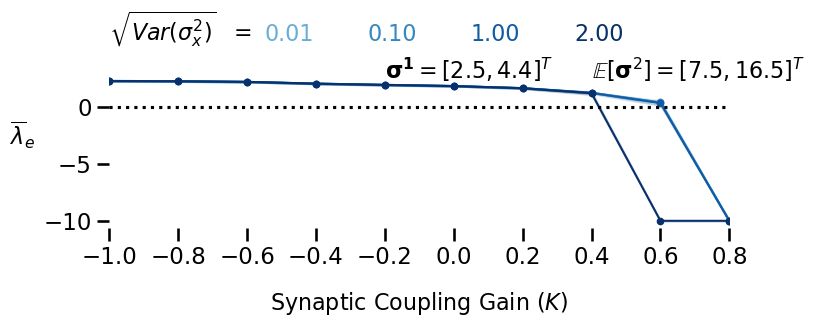

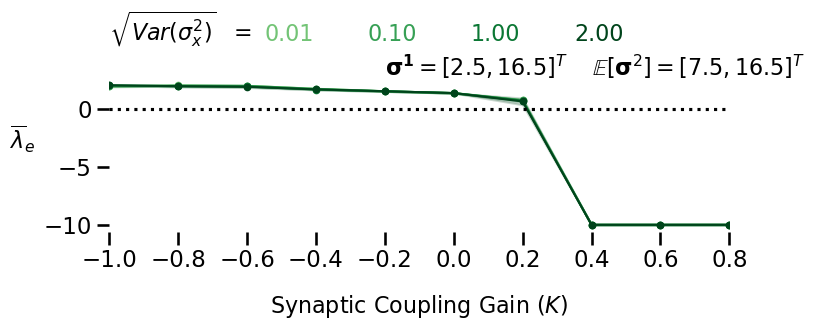

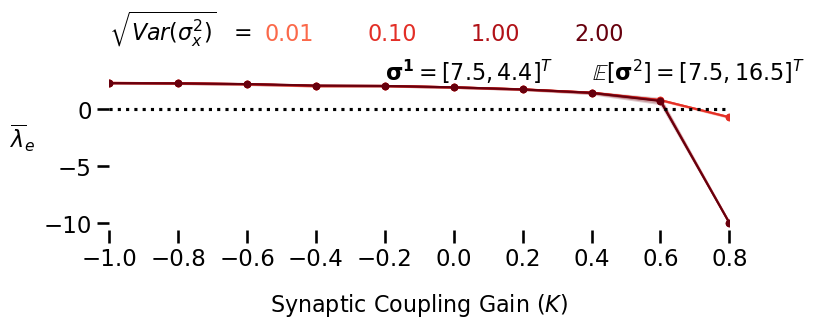

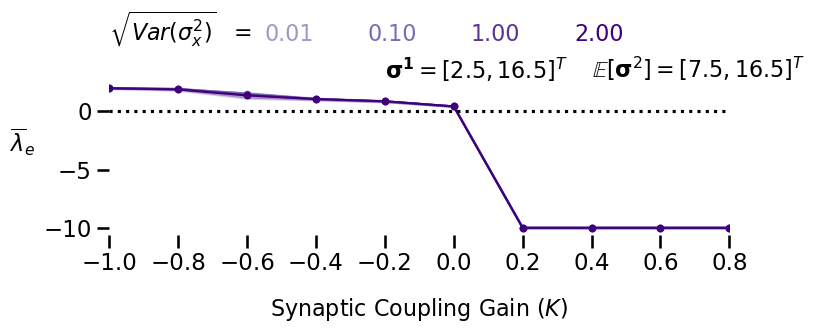

In [19]:
colors= plt.get_cmap('Blues')
colorIter = iter(colors(np.linspace(0.5, 1, len(sigVar))))

plt.figure(figsize=(8, 2))
plt.text(-1, 5.8, r'$\sqrt{Var(\sigma_x^2)} ~~= $', color = 'k',  fontsize=16)

for i in range(len(sigVar)):
    color = next(colorIter)
    plt.plot(kVals[:-1], Lyap[i, :, 0], '.-', color=color, linewidth=1.5)
    plt.fill_between(kVals[:-1], Lyap[i, :, 0] - LyapVar[i, :, 0], Lyap[i, :, 0] + LyapVar[i, :, 0], color=color, alpha=0.2)
    plt.text(-0.55 + 0.3 * i, 5.8, f"{sigVar[i]:.2f}", color = color,  fontsize=16)

plt.text(-0.2, 2.5, r"$\mathbf{\sigma^1} = [2.5, 4.4]^T$", color = "k",  fontsize=16)
plt.text(0.4, 2.5, r"$\mathbb{E}[\mathbf{\sigma}^2] = [7.5, 16.5]^T$", color = "k",  fontsize=16)
for pos in ["right", "left", "top", "bottom"]:
    plt.gca().spines[pos].set_visible(False)

plt.axhline(0, color='k', linestyle=':')
plt.xlim(kMin, kVals[-2])
plt.ylabel(r"$\overline{\lambda}_e$", fontsize=16, rotation=0, labelpad=15)
plt.xlabel(r"Synaptic Coupling Gain $(K)$", fontsize=16, labelpad=15)
plt.savefig(os.path.join(figureroot, f"Imod_{iE:.3f}mV_sige_2.5_sigi_4.4_K_Het2Node.png"), dpi=300, bbox_inches="tight")
plt.show()

#----------------------------------------------------------------------------------------------------------------------------#
colors= plt.get_cmap('Greens')
colorIter = iter(colors(np.linspace(0.5, 1, len(sigVar))))

plt.figure(figsize=(8, 2))
plt.text(-1, 5.8, r'$\sqrt{Var(\sigma_x^2)} ~~= $', color = 'k',  fontsize=16)

for i in range(len(sigVar)):
    color = next(colorIter)
    plt.plot(kVals[:-1], Lyap[i, :, 1], '.-', color=color, linewidth=1.5)
    plt.fill_between(kVals[:-1], Lyap[i, :, 1] - LyapVar[i, :, 1], Lyap[i, :, 1] + LyapVar[i, :, 1], color=color, alpha=0.2)
    plt.text(-0.55 + 0.3 * i, 5.8, f"{sigVar[i]:.2f}", color = color,  fontsize=16)

plt.text(-0.2, 2.8, r"$\mathbf{\sigma^1} = [2.5, 16.5]^T$", color = "k",  fontsize=16)
plt.text(0.4, 2.8, r"$\mathbb{E}[\mathbf{\sigma}^2] = [7.5, 16.5]^T$", color = "k",  fontsize=16)
for pos in ["right", "left", "top", "bottom"]:
    plt.gca().spines[pos].set_visible(False)

plt.axhline(0, color='k', linestyle=':')
plt.xlim(kMin, kVals[-2])
plt.ylabel(r"$\overline{\lambda}_e$", fontsize=16, rotation=0, labelpad=15)
plt.xlabel(r"Synaptic Coupling Gain $(K)$", fontsize=16, labelpad=15)
plt.savefig(os.path.join(figureroot, f"Imod_{iE:.3f}mV_sige_2.5_sigi_16.5_K_Het2Node.png"), dpi=300, bbox_inches="tight")
plt.show()

#----------------------------------------------------------------------------------------------------------------------------#
colors= plt.get_cmap('Reds')
colorIter = iter(colors(np.linspace(0.5, 1, len(sigVar))))

plt.figure(figsize=(8, 2))
plt.text(-1, 6, r'$\sqrt{Var(\sigma_x^2)} ~~= $', color = 'k',  fontsize=16)

for i in range(len(sigVar)):
    color = next(colorIter)
    plt.plot(kVals[:-1], Lyap[i, :, 2], '.-', color=color, linewidth=1.5)
    plt.fill_between(kVals[:-1], Lyap[i, :, 2] - LyapVar[i, :, 2], Lyap[i, :, 2] + LyapVar[i, :, 2], color=color, alpha=0.2)
    plt.text(-0.55 + 0.3 * i, 6, f"{sigVar[i]:.2f}", color = color,  fontsize=16)

plt.text(-0.2, 2.5, r"$\mathbf{\sigma^1} = [7.5, 4.4]^T$", color = "k",  fontsize=16)
plt.text(0.4, 2.5, r"$\mathbb{E}[\mathbf{\sigma}^2] = [7.5, 16.5]^T$", color = "k",  fontsize=16)
for pos in ["right", "left", "top", "bottom"]:
    plt.gca().spines[pos].set_visible(False)

plt.axhline(0, color='k', linestyle=':')
plt.xlim(kMin, kVals[-2])
plt.ylabel(r"$\overline{\lambda}_e$", fontsize=16, rotation=0, labelpad=15)
plt.xlabel(r"Synaptic Coupling Gain $(K)$", fontsize=16, labelpad=15)
plt.savefig(os.path.join(figureroot, f"Imod_{iE:.3f}mV_sige_7.5_sigi_4.4_K_Het2Node.png"), dpi=300, bbox_inches="tight")
plt.show()

#----------------------------------------------------------------------------------------------------------------------------#
colors= plt.get_cmap('Purples')
colorIter = iter(colors(np.linspace(0.5, 1, len(sigVar))))

plt.figure(figsize=(8, 2))
plt.text(-1, 6, r'$\sqrt{Var(\sigma_x^2)} ~~= $', color = 'k',  fontsize=16)

for i in range(len(sigVar)):
    color = next(colorIter)
    plt.plot(kVals[:-1], Lyap[i, :, 3], '.-', color=color, linewidth=1.5)
    plt.fill_between(kVals[:-1], Lyap[i, :, 3] - LyapVar[i, :, 3], Lyap[i, :, 3] + LyapVar[i, :, 3], color=color, alpha=0.2)
    plt.text(-0.55 + 0.3 * i, 6, f"{sigVar[i]:.2f}", color = color,  fontsize=16)

plt.text(-0.2, 2.8, r"$\mathbf{\sigma^1} = [2.5, 16.5]^T$", color = "k",  fontsize=16)
plt.text(0.4, 2.9, r"$\mathbb{E}[\mathbf{\sigma}^2] = [7.5, 16.5]^T$", color = "k",  fontsize=16)
for pos in ["right", "left", "top", "bottom"]:
    plt.gca().spines[pos].set_visible(False)

plt.axhline(0, color='k', linestyle=':')
plt.xlim(kMin, kVals[-2])
plt.ylabel(r"$\overline{\lambda}_e$", fontsize=16, rotation=0, labelpad=15)
plt.xlabel(r"Synaptic Coupling Gain $(K)$", fontsize=16, labelpad=15)   
plt.savefig(os.path.join(figureroot, f"Imod_{iE:.3f}mV_sige_7.5_sigi_16.5_K_Het2Node.png"), dpi=300, bbox_inches="tight")
plt.show()

In [29]:
Lyap = np.zeros((len(sigVar), len(iPert), 4))
LyapVar = np.zeros((len(sigVar), len(iPert), 4))
sigE = np.zeros((len(sigVar), len(iPert), 4))
sigI = np.zeros((len(sigVar), len(iPert), 4))

K = -0.2

for varInd in range(len(sigVar)):
    _temp = []
    _sortpaths = []

    for path_ in file_paths:
        if f"_K_{K:.2f}" not in path_ or f"_sigVar_{sigVar[varInd]:.2f}" not in path_:
            continue
        Basename = os.path.basename(path_).split('.pkl')[0]
        I = float(Basename.split('_ie_')[-1].split("_sigVar_")[0])
        _temp.append(I)
        _sortpaths.append(path_)

    _temp = np.array(_temp)
    Isort = np.argsort(_temp)

    _sortpaths = np.array(_sortpaths)
    _sortpaths = _sortpaths[Isort]
    iVals = _temp[Isort]
    iVals -= params['i_e2']

    for nf, path_ in enumerate(_sortpaths):
        lyap_results = pickle.load(open(path_, 'rb'))

        _lyapMean = lyap_results['n1_mean']
        _lyapVar = lyap_results['n1_var']

        Lyap[varInd, nf, 0] = _lyapMean[0, 0]; LyapVar[varInd, nf, 0] = _lyapVar[0, 0]
        Lyap[varInd, nf, 1] = _lyapMean[0, -1]; LyapVar[varInd, nf, 1] = _lyapVar[0, -1]
        Lyap[varInd, nf, 2] = _lyapMean[-1, 0]; LyapVar[varInd, nf, 2] = _lyapVar[-1, 0]
        Lyap[varInd, nf, 3] = _lyapMean[-1, -1]; LyapVar[varInd, nf, 3] = _lyapVar[-1, -1]

if len(Lyap[Lyap != -np.inf].flatten()) == 0:
    minValue = -10
else:
    minValue = min(-10, min(Lyap[Lyap != -np.inf]))
Lyap[Lyap == -np.inf] = minValue

nanMask = np.isnan(LyapVar)
LyapVar[nanMask] = 0.0   

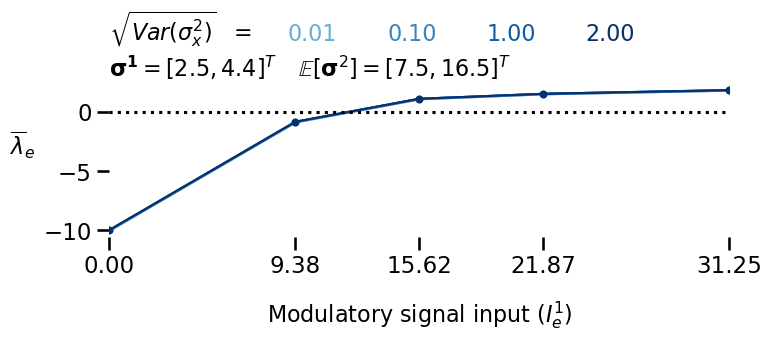

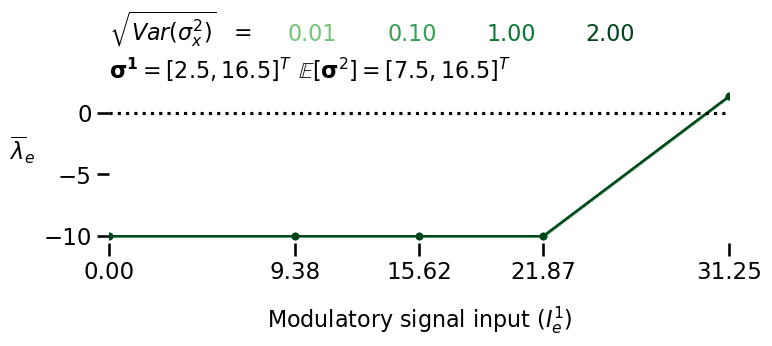

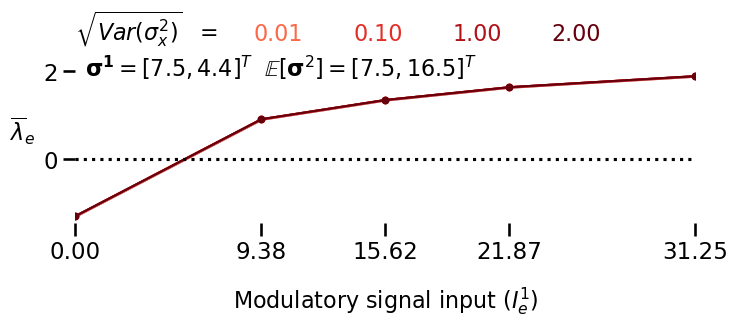

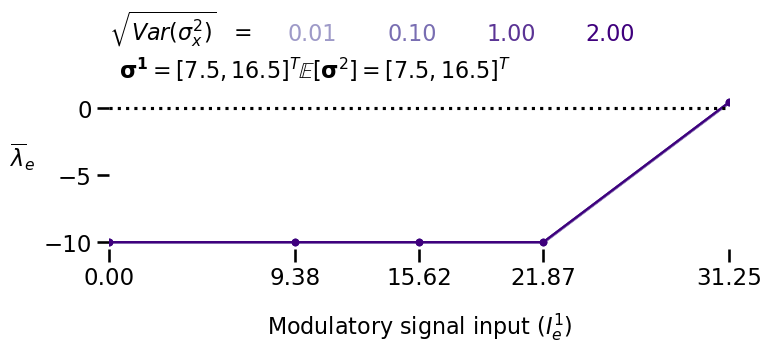

In [28]:
colors= plt.get_cmap('Blues')
colorIter = iter(colors(np.linspace(0.5, 1, len(sigVar))))

plt.figure(figsize=(8, 2))
plt.text(0, 6, r'$\sqrt{Var(\sigma_x^2)} ~~= $', color = 'k',  fontsize=16)

for i in range(len(sigVar)):
    color = next(colorIter)
    plt.plot(iPert, Lyap[i, :, 0], '.-', color=color, linewidth=1.5)
    plt.fill_between(iPert, Lyap[i, :, 0] - LyapVar[i, :, 0], Lyap[i, :, 0] + LyapVar[i, :, 0], color=color, alpha=0.2)
    plt.text(9 + 5 * i, 6, f"{sigVar[i]:.2f}", color = color,  fontsize=16)

plt.text(0, 3.0, r"$\mathbf{\sigma^1}= [2.5, 4.4]^T$", color = "k",  fontsize=16)
plt.text(9.5, 3.0, r"$\mathbb{E}[\mathbf{\sigma}^2] = [7.5, 16.5]^T$", color = "k",  fontsize=16)
for pos in ["right", "left", "top", "bottom"]:
    plt.gca().spines[pos].set_visible(False)

plt.axhline(0, color='k', linestyle=':')
plt.xlim(min(iPert), max(iPert))
plt.xticks(iPert)
plt.ylabel(r"$\overline{\lambda}_e$", fontsize=16, rotation=0, labelpad=15)
plt.xlabel(r"Modulatory signal input $(I^1_e)$", fontsize=16, labelpad=15)
plt.savefig(os.path.join(figureroot, f"K_{K:.2f}_sige_2.5_sigi_4.4_I_Het2Node.png"), dpi=300, bbox_inches="tight")
plt.show()

#----------------------------------------------------------------------------------------------------------------------------#
colors= plt.get_cmap('Greens')
colorIter = iter(colors(np.linspace(0.5, 1, len(sigVar))))

plt.figure(figsize=(8, 2))
plt.text(0., 5.8, r'$\sqrt{Var(\sigma_x^2)} ~~= $', color = 'k',  fontsize=16)

for i in range(len(sigVar)):
    color = next(colorIter)
    plt.plot(iPert, Lyap[i, :, 1], '.-', color=color, linewidth=1.5)
    plt.fill_between(iPert, Lyap[i, :, 1] - LyapVar[i, :, 1], Lyap[i, :, 1] + LyapVar[i, :, 1], color=color, alpha=0.2)
    plt.text(9 + 5 * i, 5.8, f"{sigVar[i]:.2f}", color = color,  fontsize=16)

plt.text(0, 2.8, r"$\mathbf{\sigma^1}= [2.5, 16.5]^T$", color = "k",  fontsize=16)
plt.text(9.5, 2.8, r"$\mathbb{E}[\mathbf{\sigma}^2] = [7.5, 16.5]^T$", color = "k",  fontsize=16)
for pos in ["right", "left", "top", "bottom"]:
    plt.gca().spines[pos].set_visible(False)

plt.axhline(0, color='k', linestyle=':')
plt.xlim(min(iPert), max(iPert))
plt.xticks(iPert)
plt.ylabel(r"$\overline{\lambda}_e$", fontsize=16, rotation=0, labelpad=15)
plt.xlabel(r"Modulatory signal input $(I^1_e)$", fontsize=16, labelpad=15)
plt.savefig(os.path.join(figureroot, f"K_{K:.2f}_sige_2.5_sigi_16.5_I_Het2Node.png"), dpi=300, bbox_inches="tight")
plt.show()

#----------------------------------------------------------------------------------------------------------------------------#
colors= plt.get_cmap('Reds')
colorIter = iter(colors(np.linspace(0.5, 1, len(sigVar))))

plt.figure(figsize=(8, 2))
plt.text(0., 2.7, r'$\sqrt{Var(\sigma_x^2)} ~~= $', color = 'k',  fontsize=16)

for i in range(len(sigVar)):
    color = next(colorIter)
    plt.plot(iPert, Lyap[i, :, 2], '.-', color=color, linewidth=1.5)
    plt.fill_between(iPert, Lyap[i, :, 2] - LyapVar[i, :, 2], Lyap[i, :, 2] + LyapVar[i, :, 2], color=color, alpha=0.2)
    plt.text(9 + 5 * i, 2.7, f"{sigVar[i]:.2f}", color = color,  fontsize=16)

plt.text(0.5, 1.9, r"$\mathbf{\sigma^1}= [7.5, 4.4]^T$", color = "k",  fontsize=16)
plt.text(9.5, 1.9, r"$\mathbb{E}[\mathbf{\sigma}^2] = [7.5, 16.5]^T$", color = "k",  fontsize=16)
for pos in ["right", "left", "top", "bottom"]:
    plt.gca().spines[pos].set_visible(False)

plt.axhline(0, color='k', linestyle=':')
plt.xlim(min(iPert), max(iPert))
plt.xticks(iPert)
plt.ylabel(r"$\overline{\lambda}_e$", fontsize=16, rotation=0, labelpad=15)
plt.xlabel(r"Modulatory signal input $(I^1_e)$", fontsize=16, labelpad=15)
plt.savefig(os.path.join(figureroot, f"K_{K:.2f}_sige_7.5_sigi_4.4_I_Het2Node.png"), dpi=300, bbox_inches="tight")
plt.show()

#----------------------------------------------------------------------------------------------------------------------------#
colors= plt.get_cmap('Purples')
colorIter = iter(colors(np.linspace(0.5, 1, len(sigVar))))

plt.figure(figsize=(8, 2))
plt.text(0., 5, r'$\sqrt{Var(\sigma_x^2)} ~~= $', color = 'k',  fontsize=16)

for i in range(len(sigVar)):
    color = next(colorIter)
    plt.plot(iPert, Lyap[i, :, 3], '.-', color=color, linewidth=1.5)
    plt.fill_between(iPert, Lyap[i, :, 3] - LyapVar[i, :, 3], Lyap[i, :, 3] + LyapVar[i, :, 3], color=color, alpha=0.2)
    plt.text(9 + 5 * i, 5, f"{sigVar[i]:.2f}", color = color,  fontsize=16)

plt.text(0.5, 2.2, r"$\mathbf{\sigma^1}= [7.5, 16.5]^T$", color = "k",  fontsize=16)
plt.text(9.5, 2.2, r"$\mathbb{E}[\mathbf{\sigma}^2] = [7.5, 16.5]^T$", color = "k",  fontsize=16)
for pos in ["right", "left", "top", "bottom"]:
    plt.gca().spines[pos].set_visible(False)

plt.axhline(0, color='k', linestyle=':')
plt.xlim(min(iPert), max(iPert))
plt.xticks(iPert)
plt.ylabel(r"$\overline{\lambda}_e$", fontsize=16, rotation=0, labelpad=15)
plt.xlabel(r"Modulatory signal input $(I^1_e)$", fontsize=16, labelpad=15)   
plt.savefig(os.path.join(figureroot, f"K_{K:.2f}_sige_7.5_sigi_16.5_I_Het2Node.png"), dpi=300, bbox_inches="tight")
plt.show()